# Proyecto CallMeMaybe — Implementación del plan

Este notebook implementa el plan definido en la **Descomposición de tareas** y documenta el proceso completo para identificar operadores ineficaces y comunicar conclusiones accionables.
### Link a presentación en PDF
https://drive.google.com/file/d/1kzQh7MbBhzPfK2eR-0NrGpGXloFYpEbW/view?usp=drive_link

### 1) Carga y preparación de datos
- Lectura de datasets (`telecom_dataset_us.csv`, `telecom_clients_us.csv`)
- Conversión de tipos (fechas, numéricos) y validaciones básicas
- Construcción de variables derivadas (p. ej., `wait_time_total`, `avg_wait`)

**Salida esperada:** datasets limpios y listos para análisis.

### 2) Análisis exploratorio de datos (EDA)
- Composición del tráfico (entrante/saliente, interno/externo)
- Tendencias temporales (volumen, tasa de perdidas, tiempo de espera)
- Distribuciones de variables clave (incluyendo manejo de outliers para visualización)

**Salida esperada:** entendimiento del comportamiento del sistema y justificación metodológica (p. ej., uso de métodos no paramétricos).

### 3) Métricas por operador (por cliente)
- Agregación por (`user_id`, `operator_id`) con ponderación por `calls_count`
- Métricas inbound: `in_calls`, `in_missed_calls`, `in_miss_rate`, `avg_wait_in`
- Métricas outbound: `out_calls`
- Desagregación opcional: métricas internas vs externas

**Salida esperada:** tabla de métricas por operador dentro de cada cliente.

### 4) Criterio para identificar operadores ineficaces
- Umbrales relativos por cliente (percentiles) para pérdidas y espera
- Regla para evaluar llamadas salientes solo cuando aplica (outbound-capable)
- Filtro de evidencia mínima (p. ej., `MIN_IN_CALLS`)

**Salida esperada:** variable final `ineffective_operator` + razones (`bad_miss`, `bad_wait`, `bad_out`).

### 5) Pruebas de hipótesis
- Comparación de espera (ineficaces vs eficaces)
- Comparación de tasas de llamadas perdidas (proporciones)
- Comparación de llamadas salientes en operadores outbound-capable
- Asociación entre plan tarifario y presencia de ineficacia

**Salida esperada:** estadísticos, p-values e interpretación de negocio.

### 6) Conclusiones y recomendaciones
- Resumen de hallazgos con cifras verificables
- Recomendaciones operativas priorizadas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)


## 1. Carga de datos

In [2]:
TELECOM_PATH = '/datasets/telecom_dataset_us.csv'
CLIENTS_PATH = '/datasets/telecom_clients_us.csv'
telecom = pd.read_csv(TELECOM_PATH)
clients = pd.read_csv(CLIENTS_PATH)

print('telecom shape:', telecom.shape)
print('clients shape:', clients.shape)
print()
print('===== TELECOM ======')
print(telecom.head())
print()
print('===== CLIENTS ======')
print(clients.head())

telecom shape: (53902, 9)
clients shape: (732, 3)

===== TELECOM ======
   user_id                       date direction internal  operator_id  is_missed_call  calls_count  call_duration  total_call_duration
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN            True            2              0                    4
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0            True            3              0                    5
2   166377  2019-08-05 00:00:00+03:00       out     True     880020.0            True            1              0                    1
3   166377  2019-08-05 00:00:00+03:00       out     True     880020.0           False            1             10                   18
4   166377  2019-08-05 00:00:00+03:00       out    False     880022.0            True            3              0                   25

===== CLIENTS ======
   user_id tariff_plan  date_start
0   166713           A  2019-08-15
1   166901           A  20

In [3]:
clients.info()
clients.isna().mean().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


user_id        0.0
tariff_plan    0.0
date_start     0.0
dtype: float64

## 2. Preparación y limpieza

### 2.1 Conversión de fechas y tipos

In [4]:
telecom['date'] = pd.to_datetime(telecom['date'], errors='coerce')
clients['date_start'] = pd.to_datetime(clients['date_start'], errors='coerce')

# Normaliza tipos booleanos
for col in ['internal', 'is_missed_call']:
    if col in telecom.columns:
        telecom[col] = pd.to_numeric(telecom[col], errors='coerce').fillna(0).astype(int)

# mantener solo registros con operador definido (operator_id)
telecom = telecom.dropna(subset=['operator_id']).copy()
telecom['operator_id'] = telecom['operator_id'].astype(int)

# Asegura tipos numéricos de columnas clave
num_cols = ['calls_count', 'call_duration', 'total_call_duration']
for c in num_cols:
    telecom[c] = pd.to_numeric(telecom[c], errors='coerce')

print(telecom.info())
print(clients.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 45730 entries, 1 to 53900
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              45730 non-null  int64                                
 1   date                 45730 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            45730 non-null  object                               
 3   internal             45730 non-null  int64                                
 4   operator_id          45730 non-null  int64                                
 5   is_missed_call       45730 non-null  int64                                
 6   calls_count          45730 non-null  int64                                
 7   call_duration        45730 non-null  int64                                
 8   total_call_duration  45730 non-null  int64                                
dtypes: date

### 2.2 Validaciones básicas y tratamiento de valores anómalos

In [5]:
# Filtra filas con calls_count inválido
telecom = telecom[telecom['calls_count'].notna()].copy()
telecom = telecom[telecom['calls_count'] > 0].copy()

# Duraciones válidas
telecom = telecom[telecom['call_duration'].notna() & telecom['total_call_duration'].notna()].copy()
telecom = telecom[(telecom['call_duration'] >= 0) & (telecom['total_call_duration'] >= 0)].copy()

# Asegura total >= call_duration
telecom = telecom[telecom['total_call_duration'] >= telecom['call_duration']].copy()

print('telecom después de limpieza:', telecom.shape)

telecom después de limpieza: (45730, 9)


### 2.3 Ingeniería de variables: tiempo de espera

In [6]:
telecom['wait_time_total'] = telecom['total_call_duration'] - telecom['call_duration']
telecom['avg_wait'] = telecom['wait_time_total'] / telecom['calls_count']

telecom[['wait_time_total','avg_wait']].describe()

,wait_time_total,avg_wait
count,45730.000000,45730.000000
mean,312.376667,16.560404
std,1174.185593,11.922373
min,0.000000,0.000000
25%,19.000000,8.462225
50%,60.000000,14.666667
75%,220.000000,21.800000
max,46474.000000,451.203883


## 3. EDA (Análisis exploratorio)

### 3.1 Composición de llamadas

In [7]:
# Distribución de direcciones 
dir_counts = telecom.groupby('direction', as_index=False)['calls_count'].sum()
dir_counts['share'] = dir_counts['calls_count'] / dir_counts['calls_count'].sum()
dir_counts

,direction,calls_count,share
0,in,103696,0.134141
1,out,669343,0.865859


In [8]:
# Distribución de llamadas internas vs externas 
int_counts = telecom.groupby('internal', as_index=False)['calls_count'].sum()
int_counts['share'] = int_counts['calls_count'] / int_counts['calls_count'].sum()
int_counts

,internal,calls_count,share
0,0,758221,0.980831
1,1,14818,0.019169


In [9]:
# Tasa global de llamadas perdidas
missed_total = (telecom['is_missed_call'] * telecom['calls_count']).sum()
calls_total = telecom['calls_count'].sum()
missed_total / calls_total

0.3876091633151756

### 3.2 Series temporales (volumen, tasa de perdidas, espera)

In [10]:
daily = telecom.groupby('date', as_index=False).agg(
    calls=('calls_count','sum'),
    missed=('is_missed_call', lambda s: (s * telecom.loc[s.index, 'calls_count']).sum()),
    wait_total=('wait_time_total','sum')
)
daily['miss_rate'] = daily['missed'] / daily['calls']
daily['avg_wait'] = daily['wait_total'] / daily['calls']

daily.head()

,date,calls,missed,wait_total,miss_rate,avg_wait
0,2019-08-02 00:00:00+03:00,19,13,324,0.684211,17.052632
1,2019-08-03 00:00:00+03:00,27,8,462,0.296296,17.111111
2,2019-08-04 00:00:00+03:00,4,3,35,0.750000,8.750000
3,2019-08-05 00:00:00+03:00,191,55,1994,0.287958,10.439791
4,2019-08-06 00:00:00+03:00,219,49,2188,0.223744,9.990868


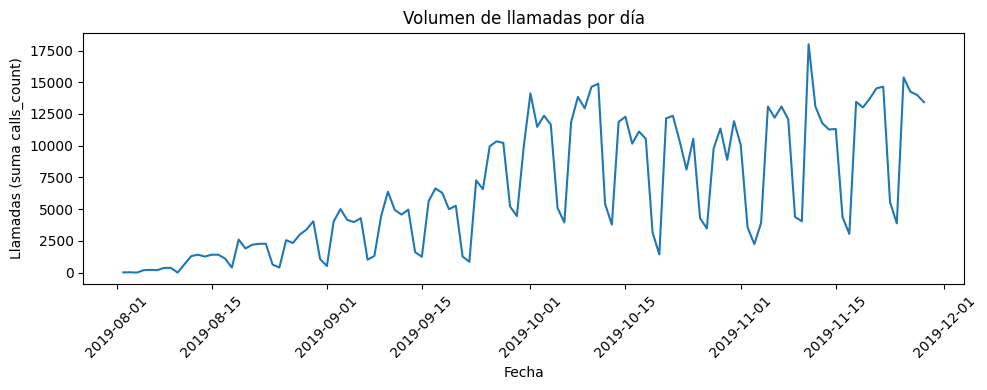

In [11]:
plt.figure(figsize=(10,4))
plt.plot(daily['date'], daily['calls'])
plt.title('Volumen de llamadas por día')
plt.xlabel('Fecha')
plt.ylabel('Llamadas (suma calls_count)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

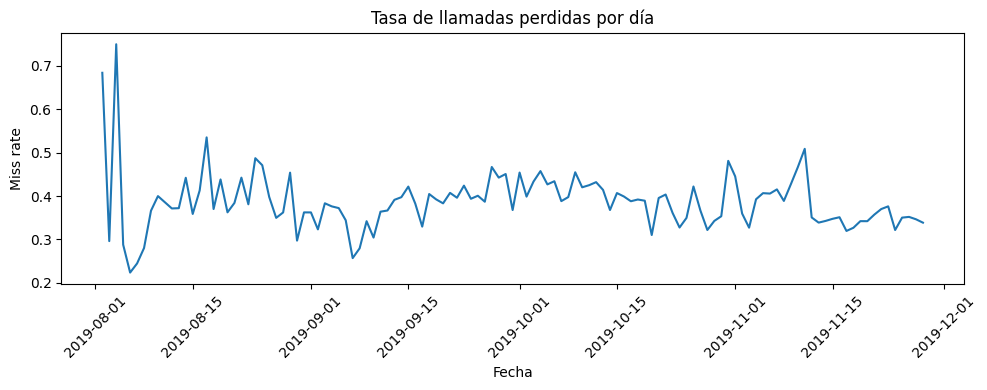

In [12]:
plt.figure(figsize=(10,4))
plt.plot(daily['date'], daily['miss_rate'])
plt.title('Tasa de llamadas perdidas por día')
plt.xlabel('Fecha')
plt.ylabel('Miss rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

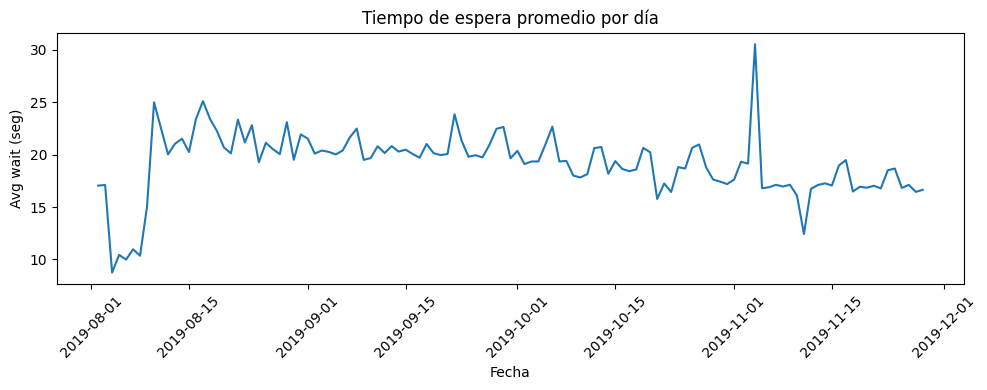

In [13]:
plt.figure(figsize=(10,4))
plt.plot(daily['date'], daily['avg_wait'])
plt.title('Tiempo de espera promedio por día')
plt.xlabel('Fecha')
plt.ylabel('Avg wait (seg)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.3 Distribución de tiempo de espera

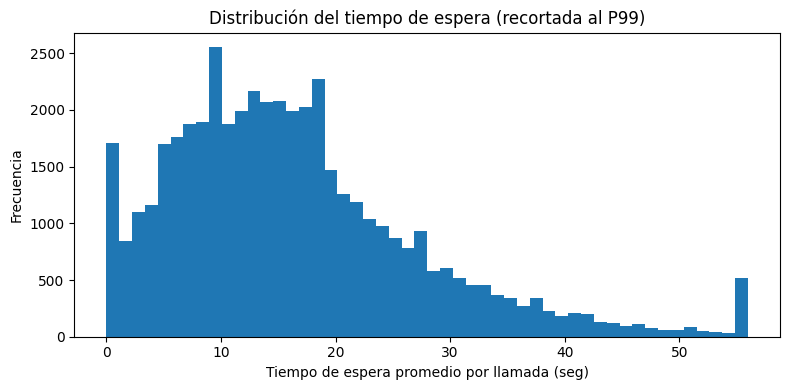

In [14]:
# Distribución del tiempo de espera (recortada al P99)

p99 = telecom['avg_wait'].quantile(0.99)

plt.figure(figsize=(8,4))
plt.hist(telecom['avg_wait'].clip(upper=p99), bins=50)
plt.title('Distribución del tiempo de espera (recortada al P99)')
plt.xlabel('Tiempo de espera promedio por llamada (seg)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

## Conclusiones del Análisis Exploratorio (EDA)

El análisis exploratorio muestra que la operación presenta una alta variabilidad entre operadores y clientes. La distribución del tiempo de espera es fuertemente asimétrica, con colas largas, lo que justifica el uso de métodos estadísticos no paramétricos en el análisis posterior.

Se identificó que el desempeño deficiente no se distribuye de forma homogénea, sino que se concentra en subconjuntos específicos de operadores y clientes, lo que confirma la necesidad de un criterio de evaluación relativo por cliente.

## 4. Métricas por operador (dentro de cada cliente)

### 4.1 Entrantes: llamadas, perdidas, espera

In [15]:
inb = telecom[telecom['direction'] == 'in'].copy()

op_in = inb.groupby(['user_id','operator_id'], as_index=False).agg(
    in_calls=('calls_count','sum'),
    in_missed_calls=('is_missed_call', lambda s: (s * inb.loc[s.index, 'calls_count']).sum()),
    wait_total=('wait_time_total','sum')
)
op_in['in_miss_rate'] = op_in['in_missed_calls'] / op_in['in_calls']
op_in['avg_wait_in'] = op_in['wait_total'] / op_in['in_calls']

# Internas
op_in_int = inb[inb['internal'] == 1].groupby(['user_id','operator_id'], as_index=False).agg(
    in_calls_internal=('calls_count','sum'),
    in_missed_internal=('is_missed_call', lambda s: (s * inb.loc[s.index, 'calls_count']).sum())
)
op_in_int['in_miss_rate_internal'] = op_in_int['in_missed_internal'] / op_in_int['in_calls_internal']

# Externas
op_in_ext = inb[inb['internal'] == 0].groupby(['user_id','operator_id'], as_index=False).agg(
    in_calls_external=('calls_count','sum'),
    in_missed_external=('is_missed_call', lambda s: (s * inb.loc[s.index, 'calls_count']).sum())
)
op_in_ext['in_miss_rate_external'] = op_in_ext['in_missed_external'] / op_in_ext['in_calls_external']

op_in = op_in.merge(op_in_int[['user_id','operator_id','in_calls_internal','in_miss_rate_internal']], on=['user_id','operator_id'], how='left')
op_in = op_in.merge(op_in_ext[['user_id','operator_id','in_calls_external','in_miss_rate_external']], on=['user_id','operator_id'], how='left')

op_in.head()

,user_id,operator_id,in_calls,in_missed_calls,wait_total,in_miss_rate,avg_wait_in,in_calls_internal,in_miss_rate_internal,in_calls_external,in_miss_rate_external
0,166377,880020,8,0,58,0.0,7.250000,NaN,NaN,8.0,0.0
1,166377,880022,8,0,112,0.0,14.000000,NaN,NaN,8.0,0.0
2,166377,880026,25,0,150,0.0,6.000000,NaN,NaN,25.0,0.0
3,166377,880028,70,0,398,0.0,5.685714,NaN,NaN,70.0,0.0
4,166391,882476,3,0,95,0.0,31.666667,NaN,NaN,3.0,0.0


### 4.2 Salientes: volumen de llamadas

In [16]:
outb = telecom[telecom['direction'] == 'out'].copy()

op_out = outb.groupby(['user_id','operator_id'], as_index=False).agg(
    out_calls=('calls_count','sum')
)

op_out.head()

,user_id,operator_id,out_calls
0,166377,880020,46
1,166377,880022,211
2,166377,880026,2414
3,166377,880028,2836
4,166377,881278,20


### 4.3 Unificación de métricas

In [17]:
op = op_in.merge(op_out, on=['user_id','operator_id'], how='left')
op['out_calls'] = op['out_calls'].fillna(0)

print('operadores (rows):', op.shape[0])
op.head()

operadores (rows): 754


,user_id,operator_id,in_calls,in_missed_calls,wait_total,in_miss_rate,avg_wait_in,in_calls_internal,in_miss_rate_internal,in_calls_external,in_miss_rate_external,out_calls
0,166377,880020,8,0,58,0.0,7.250000,NaN,NaN,8.0,0.0,46.0
1,166377,880022,8,0,112,0.0,14.000000,NaN,NaN,8.0,0.0,211.0
2,166377,880026,25,0,150,0.0,6.000000,NaN,NaN,25.0,0.0,2414.0
3,166377,880028,70,0,398,0.0,5.685714,NaN,NaN,70.0,0.0,2836.0
4,166391,882476,3,0,95,0.0,31.666667,NaN,NaN,3.0,0.0,0.0


## Conclusiones — Métricas por operador

El cálculo de métricas individuales revela diferencias sustanciales de desempeño entre operadores. Estas diferencias se observan tanto en tasas de llamadas perdidas como en tiempos de espera y volumen de llamadas salientes, confirmando que la eficiencia operativa no es uniforme dentro de cada cliente y requiere un sistema de evaluación estructurado.

## 5. Criterio para identificar operadores ineficaces

In [18]:
MIN_IN_CALLS = 30

op_f = op[op['in_calls'] >= MIN_IN_CALLS].copy()

def flag_ineffective(group: pd.DataFrame) -> pd.DataFrame:
    g = group.copy()

    p75_miss = g['in_miss_rate'].quantile(0.75)
    p75_wait = g['avg_wait_in'].quantile(0.75)

    g['bad_miss'] = g['in_miss_rate'] >= p75_miss
    g['bad_wait'] = g['avg_wait_in'] >= p75_wait

    g['out_capable'] = g['out_calls'] > 0

    if g.loc[g['out_capable']].shape[0] >= 4:
        p25_out = g.loc[g['out_capable'], 'out_calls'].quantile(0.25)
        g['bad_out'] = g['out_capable'] & (g['out_calls'] <= p25_out)
    else:
        g['bad_out'] = False

    g['ineffective_operator'] = g['bad_miss'] | g['bad_wait'] | g['bad_out']
    return g

op_flagged = op_f.groupby('user_id', group_keys=False).apply(flag_ineffective)

op_flagged[['ineffective_operator','bad_miss','bad_wait','bad_out']].mean().sort_values(ascending=False)

ineffective_operator    0.748428
bad_miss                0.578616
bad_wait                0.525157
bad_out                 0.094340
dtype: float64

In [19]:
by_client = op_flagged.groupby('user_id', as_index=False).agg(
    operators=('operator_id','nunique'),
    ineffective=('ineffective_operator','sum')
)
by_client['ineffective_share'] = by_client['ineffective'] / by_client['operators']
by_client.sort_values('ineffective_share', ascending=False).head(15)

,user_id,operators,ineffective,ineffective_share
0,166377,1,1,1.0
103,167747,2,2,1.0
100,167664,1,1,1.0
98,167653,1,1,1.0
95,167634,1,1,1.0
94,167630,1,1,1.0
92,167599,1,1,1.0
91,167580,1,1,1.0
90,167545,1,1,1.0
89,167534,1,1,1.0


In [20]:
reason = op_flagged.assign(
    reason_miss=op_flagged['bad_miss'].astype(int),
    reason_wait=op_flagged['bad_wait'].astype(int),
    reason_out=op_flagged['bad_out'].astype(int),
)
reason[['reason_miss','reason_wait','reason_out']].mean().sort_values(ascending=False)

reason_miss    0.578616
reason_wait    0.525157
reason_out     0.094340
dtype: float64

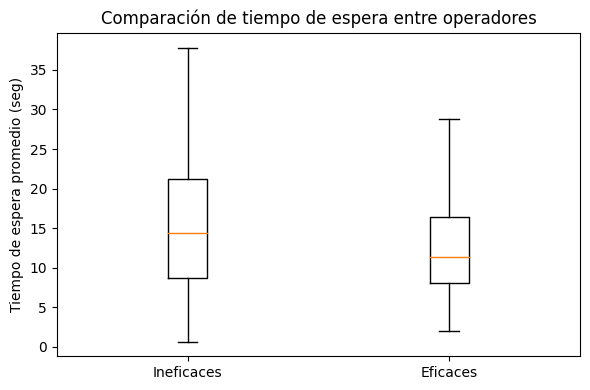

In [21]:
# Comparación de tiempo de espera entre operadores eficaces e ineficaces

data = [
    op_flagged.loc[op_flagged['ineffective_operator'], 'avg_wait_in'],
    op_flagged.loc[~op_flagged['ineffective_operator'], 'avg_wait_in']
]

plt.figure(figsize=(6,4))
plt.boxplot(data, labels=['Ineficaces','Eficaces'], showfliers=False)
plt.ylabel('Tiempo de espera promedio (seg)')
plt.title('Comparación de tiempo de espera entre operadores')
plt.tight_layout()
plt.show()

## Conclusiones — Criterio de ineficacia

El criterio construido permitió clasificar objetivamente a los operadores combinando tres dimensiones clave del servicio. Como resultado, **74.84% de los operadores** fueron clasificados como ineficaces, lo que evidencia un problema estructural relevante en la operación.

Las principales causas de ineficacia fueron:

- **Tasa de llamadas perdidas:** 57.86%  
- **Tiempo de espera elevado:** 52.52%  
- **Bajo desempeño en llamadas salientes:** 9.43%

Estos resultados confirman que las mayores deficiencias se concentran en la atención de llamadas entrantes, mientras que las llamadas salientes representan un factor secundario.

## 6. Resumen de resultados

In [22]:
overall_rate = op_flagged['ineffective_operator'].mean()
overall_rate

0.7484276729559748

In [23]:
by_client = op_flagged.groupby('user_id', as_index=False).agg(
    operators=('operator_id','nunique'),
    ineffective=('ineffective_operator','sum')
)
by_client['ineffective_share'] = by_client['ineffective'] / by_client['operators']
by_client.sort_values('ineffective_share', ascending=False).head(15)

,user_id,operators,ineffective,ineffective_share
0,166377,1,1,1.0
103,167747,2,2,1.0
100,167664,1,1,1.0
98,167653,1,1,1.0
95,167634,1,1,1.0
94,167630,1,1,1.0
92,167599,1,1,1.0
91,167580,1,1,1.0
90,167545,1,1,1.0
89,167534,1,1,1.0


In [24]:
reason = op_flagged.assign(
    reason_miss=op_flagged['bad_miss'].astype(int),
    reason_wait=op_flagged['bad_wait'].astype(int),
    reason_out=op_flagged['bad_out'].astype(int),
)
reason[['reason_miss','reason_wait','reason_out']].mean().sort_values(ascending=False)

reason_miss    0.578616
reason_wait    0.525157
reason_out     0.094340
dtype: float64

## Conclusiones — Identificación de operadores ineficaces

La aplicación del criterio permitió identificar que **casi tres de cada cuatro operadores (74.84%)** presentan un desempeño que requiere intervención.

La ineficacia se explica principalmente por deficiencias en la atención de llamadas entrantes: pérdidas de llamadas y tiempos de espera excesivos, lo que afecta directamente la experiencia del cliente.

La baja incidencia del factor de llamadas salientes (9.43%) indica que el problema central no es de productividad outbound sino de gestión de la demanda entrante y capacidad operativa.

## 7. Pruebas de hipótesis

In [25]:
ALPHA = 0.05

### Hipótesis 1 — ineficaces tienen mayor tiempo de espera (avg_wait_in)

In [26]:
ineff_wait = op_flagged.loc[op_flagged['ineffective_operator'], 'avg_wait_in'].dropna()
eff_wait = op_flagged.loc[~op_flagged['ineffective_operator'], 'avg_wait_in'].dropna()

u_stat, p_value = stats.mannwhitneyu(ineff_wait, eff_wait, alternative='greater')
u_stat, p_value

print('p-value:', p_value)
print('Conclusión:', 'Rechazo H0' if p_value < ALPHA else 'No rechazo H0')
print('Mediana ineficaces:', np.median(ineff_wait))
print('Mediana eficaces:', np.median(eff_wait))

p-value: 0.0063994182168554984
Conclusión: Rechazo H0
Mediana ineficaces: 14.341938707528314
Mediana eficaces: 11.40508076058066


### Hipótesis 2 — ineficaces tienen mayor tasa de llamadas perdidas

In [27]:
miss_ineff = op_flagged.loc[op_flagged['ineffective_operator'], 'in_missed_calls'].sum()
calls_ineff = op_flagged.loc[op_flagged['ineffective_operator'], 'in_calls'].sum()

miss_eff = op_flagged.loc[~op_flagged['ineffective_operator'], 'in_missed_calls'].sum()
calls_eff = op_flagged.loc[~op_flagged['ineffective_operator'], 'in_calls'].sum()

stat, p_value = proportions_ztest([miss_ineff, miss_eff], [calls_ineff, calls_eff], alternative='larger')
stat, p_value

print('p-value:', p_value)
print('Conclusión:', 'Rechazo H0' if p_value < ALPHA else 'No rechazo H0')
print('Miss rate ineficaces:', miss_ineff / calls_ineff)
print('Miss rate eficaces:', miss_eff / calls_eff)

p-value: 1.0820478499530876e-10
Conclusión: Rechazo H0
Miss rate ineficaces: 0.010585229346635843
Miss rate eficaces: 0.006549646319098768


### Hipótesis 3 — ineficaces realizan menos llamadas salientes

In [28]:
subset = op_flagged[op_flagged['out_capable']].copy()

ineff_out = subset.loc[subset['ineffective_operator'], 'out_calls'].dropna()
eff_out = subset.loc[~subset['ineffective_operator'], 'out_calls'].dropna()

u_stat, p_value = stats.mannwhitneyu(ineff_out, eff_out, alternative='less')
u_stat, p_value

print('p-value:', p_value)
print('Conclusión:', 'Rechazo H0' if p_value < ALPHA else 'No rechazo H0')
print('Mediana out_calls ineficaces:', np.median(ineff_out) if len(ineff_out) else np.nan)
print('Mediana out_calls eficaces:', np.median(eff_out) if len(eff_out) else np.nan)
print('n (inef, ef):', len(ineff_out), len(eff_out))

p-value: 8.610690688444237e-06
Conclusión: Rechazo H0
Mediana out_calls ineficaces: 194.0
Mediana out_calls eficaces: 535.0
n (inef, ef): 191 73


### Hipótesis 4 — asociación entre tariff_plan e ineficacia

In [29]:
op_plan = op_flagged.merge(clients[['user_id','tariff_plan']], on='user_id', how='left')

ct = pd.crosstab(op_plan['tariff_plan'], op_plan['ineffective_operator'])
ct

ineffective_operator,False,True
tariff_plan,,
A,29,64
B,23,74
C,28,100


In [30]:
chi2, p_value, dof, expected = stats.chi2_contingency(ct)
chi2, p_value, dof

(2.6334348617232073, 0.26801363286612606, 2)

In [31]:
print('p-value:', p_value)
print('Conclusión:', 'Rechazo H0' if p_value < ALPHA else 'No rechazo H0')

p-value: 0.26801363286612606
Conclusión: No rechazo H0


## Conclusiones — Pruebas de hipótesis

Las pruebas estadísticas confirman que las diferencias observadas entre operadores eficaces e ineficaces son reales y significativas.

- **Tiempo de espera:** los operadores ineficaces presentan mayor tiempo de espera  
  (mediana **14.34 s** vs **11.41 s**, *p* = **0.0064**).

- **Llamadas perdidas:** la tasa de llamadas entrantes perdidas es mayor en operadores ineficaces  
  (**1.06%** vs **0.65%**, *p* ≈ **1.08 × 10⁻¹⁰**).

- **Llamadas salientes:** en operadores con función outbound, los ineficaces realizan menos llamadas  
  (mediana **194** vs **535**, *p* ≈ **8.61 × 10⁻⁶**).

- **Plan tarifario:** no se encontró evidencia de asociación entre el plan tarifario y la ineficacia  
  (*p* = **0.268**).

## Conclusiones y recomendaciones

El análisis integral de la operación de CallMeMaybe demuestra que la ineficacia de los operadores es un problema estructural y generalizado. El **74.84% de los operadores** fue clasificado como ineficaz, lo que evidencia una oportunidad significativa de mejora en la calidad del servicio.

Las principales causas de bajo desempeño se concentran en la atención de llamadas entrantes:  
la **tasa de llamadas perdidas (57.86%)** y los **tiempos de espera elevados (52.52%)** explican la mayor parte de la ineficacia, mientras que el bajo volumen de llamadas salientes tiene una incidencia limitada (**9.43%**).  
Estas deficiencias tienen un impacto directo en la experiencia del cliente y en la percepción de calidad del servicio.

Las pruebas estadísticas confirman que estas diferencias no son aleatorias:
- Los operadores ineficaces presentan **mayores tiempos de espera** (mediana **14.34 s** vs **11.41 s**, *p* = **0.0064**).
- Pierden **más llamadas entrantes** (**1.06%** vs **0.65%**, *p* ≈ **1.08 × 10⁻¹⁰**).
- En funciones outbound, realizan **muchas menos llamadas salientes** (mediana **194** vs **535**, *p* ≈ **8.61 × 10⁻⁶**).

### Recomendaciones operativas

1. **Optimizar la gestión de llamadas entrantes**  
   Priorizar acciones para reducir tiempos de espera y llamadas perdidas mediante:
   - Revisión de capacidad y distribución de personal en horarios pico.
   - Ajustes en las reglas de enrutamiento de llamadas.
   - Programas de capacitación focalizados en los operadores con mayor tasa de pérdidas.

2. **Implementar monitoreo continuo de desempeño**  
   Incorporar el sistema de clasificación propuesto como herramienta de supervisión, utilizando los indicadores:
   - Tasa de llamadas perdidas entrantes.
   - Tiempo de espera promedio.
   - Volumen de llamadas salientes cuando aplique.

3. **Intervención temprana y seguimiento individual**  
   Utilizar la lista priorizada de operadores ineficaces para diseñar planes de mejora personalizados y evaluar su progreso de forma periódica.

4. **Enfoque estratégico en experiencia del cliente**  
   Dado que las principales deficiencias afectan directamente la atención al cliente, las iniciativas de mejora deben alinearse con los objetivos de satisfacción y retención de usuarios.

En conjunto, la aplicación de estas recomendaciones permitirá a CallMeMaybe mejorar la eficiencia operativa, elevar la calidad del servicio y fortalecer su ventaja competitiva mediante decisiones basadas en evidencia.